In [21]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

## Question 1


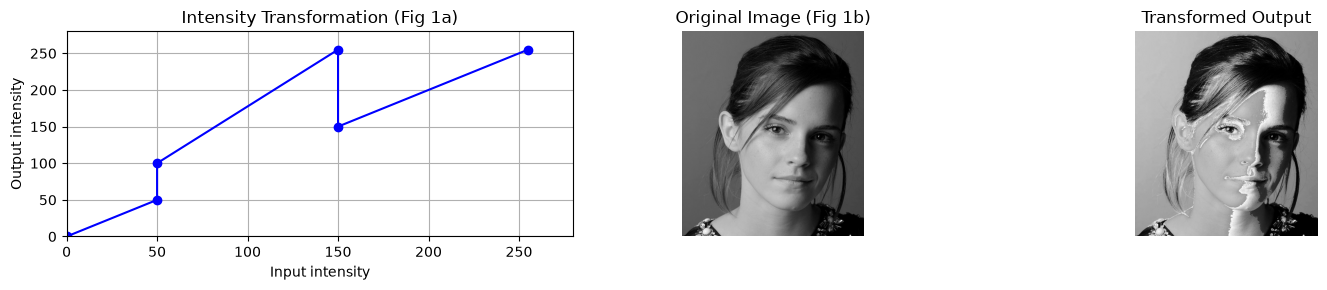

In [32]:
def intensity_transform(im, breakpoints):
    """
    Applies a piecewise linear intensity transformation.
    breakpoints: List of tuples (input_intensity, output_intensity)
    """
    xp, fp = zip(*breakpoints)
    
    # np.interp provides efficient, vectorized 1D linear interpolation
    transformed_im = np.interp(im, xp, fp).astype(np.uint8)
    return transformed_im

# Load the image
img = cv.imread('D:\\EN3160_Assignment_01\\images\\q1.jpeg', cv.IMREAD_GRAYSCALE) 
assert img is not None, "Error: Image not found. Check your file path."

breakpoints = [(0, 0), (50,50),(50,100),(150,255), (150, 150), (255, 255)] 

transformed_img = intensity_transform(img, breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(15, 3))

# 1. Transformation Plot
xp, fp = zip(*breakpoints)
ax[0].plot(xp, fp, marker='o', color='b', linestyle='-')
ax[0].set_title('Intensity Transformation (Fig 1a)')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].set_xlim([0, 280])
ax[0].set_ylim([0, 280])
ax[0].grid(True)

# 2. Original Image
ax[1].imshow(img, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Original Image (Fig 1b)')
ax[1].axis('off')

# 3. Transformed Image
ax[2].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Transformed Output')
ax[2].axis('off')

plt.tight_layout()
plt.show()

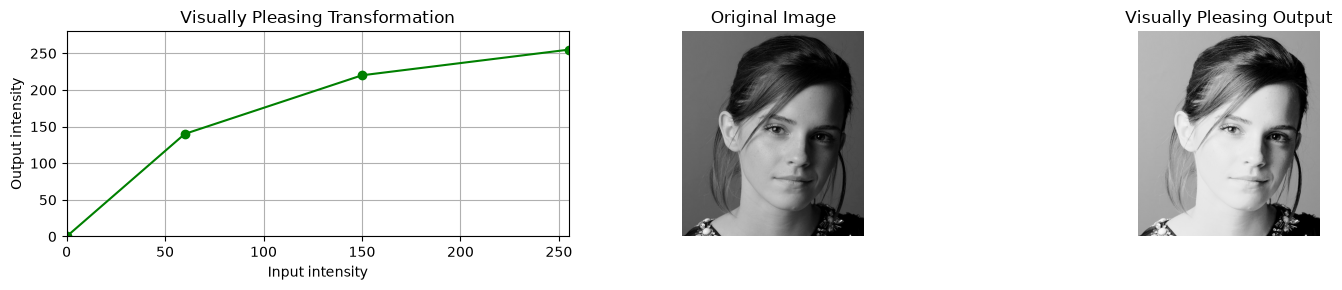

In [33]:
# Breakpoints designed to brighten the underexposed image
pleasing_breakpoints = [(0, 0), (60, 140), (150, 220), (255, 255)]

assert img is not None, "Error: Image not found."

pleasing_transformed_img = intensity_transform(img, pleasing_breakpoints)

fig, ax = plt.subplots(1, 3, figsize=(15, 3))

# 1. Transformation Plot
xp, fp = zip(*pleasing_breakpoints)
ax[0].plot(xp, fp, marker='o', color='g', linestyle='-')
ax[0].set_title('Visually Pleasing Transformation')
ax[0].set_xlabel('Input intensity')
ax[0].set_ylabel('Output intensity')
ax[0].set_xlim([0, 255])
ax[0].set_ylim([0, 280])
ax[0].grid(True)

# 2. Original Image
ax[1].imshow(img, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Original Image')
ax[1].axis('off')

# 3. Transformed Image
ax[2].imshow(pleasing_transformed_img, cmap='gray', vmin=0, vmax=255)
ax[2].set_title('Visually Pleasing Output')
ax[2].axis('off')

plt.tight_layout()
plt.show()

## Question 2

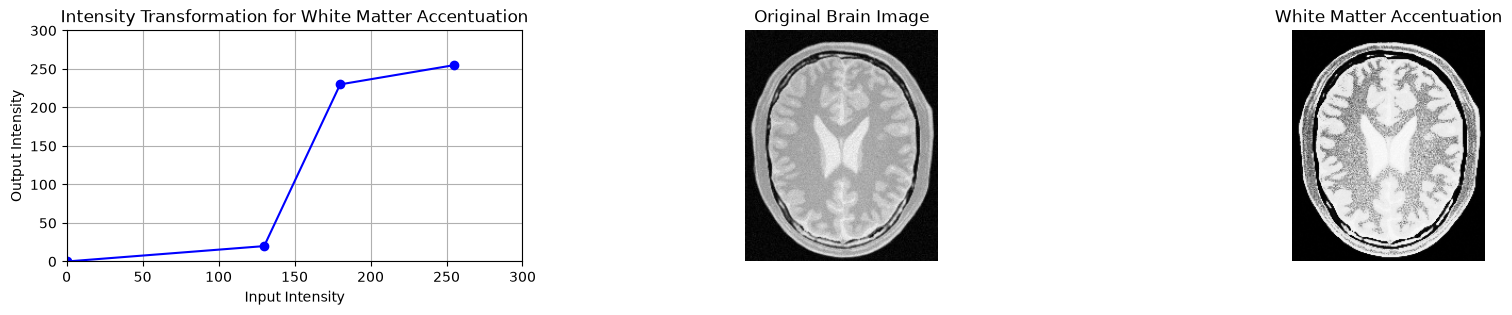

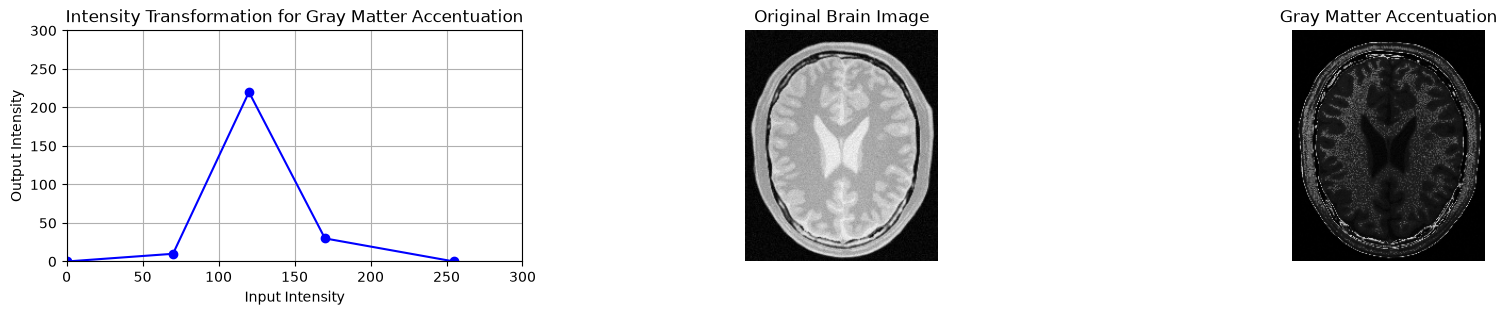

In [31]:
def display_segmentation_results(img_orig, img_transformed, points, target_name):
    """
    Helper function to plot the original image, transformation curve, and result.
    """
    # Unpack breakpoints directly into x and y coordinate tuples
    x_coords, y_coords = zip(*points)
    
    fig, axes = plt.subplots(1, 3, figsize=(20, 3))
    
    # Transformation Plot
    axes[0].plot(x_coords, y_coords, marker='o', color='blue', linestyle='-')
    axes[0].set_title(f'Intensity Transformation for {target_name}')
    axes[0].set_xlabel('Input Intensity')
    axes[0].set_ylabel('Output Intensity')
    axes[0].set_xlim([0, 300]) 
    axes[0].set_ylim([0, 300])
    axes[0].grid(True)

    # Original Image
    axes[1].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
    axes[1].set_title('Original Brain Image')     
    axes[1].axis('off') 
        
    # Transformed Image
    axes[2].imshow(img_transformed, cmap='gray', vmin=0, vmax=255)
    axes[2].set_title(target_name)
    axes[2].axis('off') 
    
    plt.show()

# Load the image and verify
im_brain = cv.imread("images\\q2.jpeg", cv.IMREAD_GRAYSCALE)
assert im_brain is not None, "Error: Image 'q2.jpeg' could not be loaded."

# --- White Matter Accentuation ---
wm_breakpoints = [
    (0, 0),
    (130, 20),   # Suppress CSF and Gray Matter
    (180, 230),  # Steep stretch across White Matter range
    (255, 255)   # Max out bright regions
]

wm_image = intensity_transform(im_brain, wm_breakpoints)
display_segmentation_results(im_brain, wm_image, wm_breakpoints, 'White Matter Accentuation')

# --- Gray Matter Accentuation ---
gm_breakpoints = [
    (0, 0),
    (70, 10),    # Suppress dark background / CSF
    (120, 220),  # Steep stretch across Gray Matter range
    (170, 30),   # Drop bright White Matter to keep Gray Matter visually dominant
    (255, 0)
]

gm_image = intensity_transform(im_brain, gm_breakpoints)
display_segmentation_results(im_brain, gm_image, gm_breakpoints, 'Gray Matter Accentuation')

## Question 3

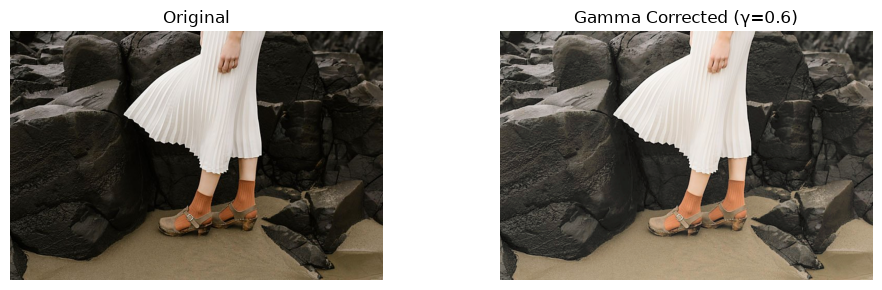

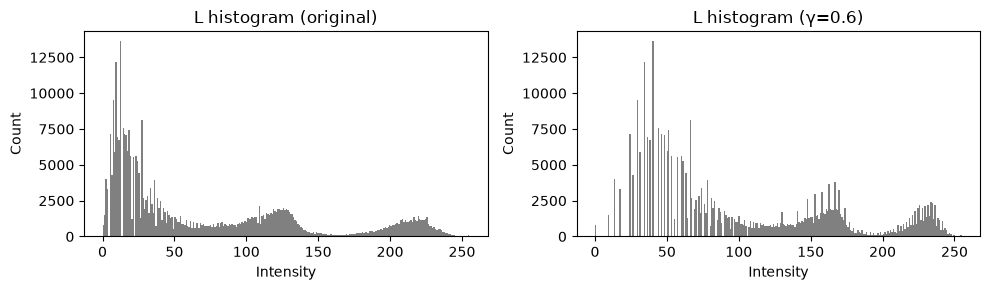

In [35]:
img_bgr = cv.imread("images/q3.jpeg")
assert img_bgr is not None, "Image not found."

img_lab = cv.cvtColor(img_bgr, cv.COLOR_BGR2LAB)
L, a, b = cv.split(img_lab)

gamma = 0.6  # < 1 brightens shadows/midtones, > 1 darkens — tune this

# Gamma correction: normalize to [0,1], apply power law, scale back
L_norm = L.astype(np.float32) / 255.0
L_gamma = np.power(L_norm, gamma)
L_corrected = np.clip(L_gamma * 255.0, 0, 255).astype(np.uint8)

img_lab_corrected = cv.merge([L_corrected, a, b])
img_corrected_bgr = cv.cvtColor(img_lab_corrected, cv.COLOR_LAB2BGR)

# --- Display images ---
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
ax[0].set_title('Original'); ax[0].axis('off')

ax[1].imshow(cv.cvtColor(img_corrected_bgr, cv.COLOR_BGR2RGB))
ax[1].set_title(f'Gamma Corrected (γ={gamma})'); ax[1].axis('off')
plt.tight_layout()
plt.show()

# --- Histograms of the L plane, before and after ---
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(L.ravel(), bins=256, range=(0,255), color='gray')
ax[0].set_title('L histogram (original)')
ax[0].set_xlabel('Intensity'); ax[0].set_ylabel('Count')

ax[1].hist(L_corrected.ravel(), bins=256, range=(0,255), color='gray')
ax[1].set_title(f'L histogram (γ={gamma})')
ax[1].set_xlabel('Intensity'); ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## Question 4

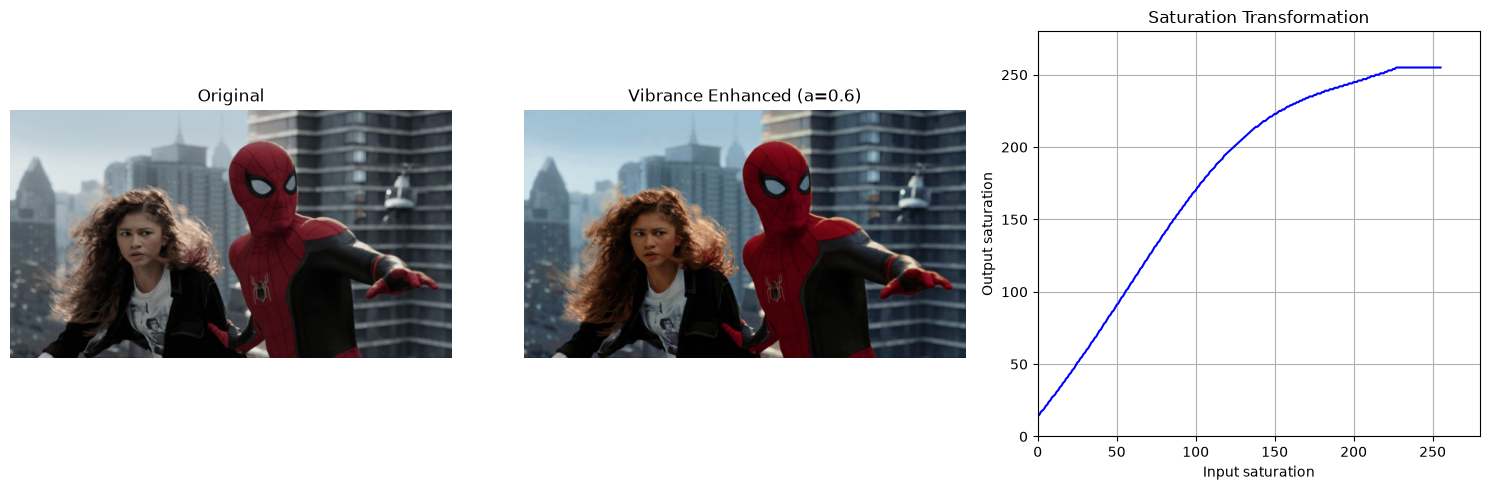

In [37]:
img_bgr = cv.imread("images/q4.jpeg")
assert img_bgr is not None, "Image not found."

# (a) Split into H, S, V
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
H, S, V = cv.split(img_hsv)

# (b)+(c) Apply vibrance transform to the saturation plane
a = 0.6      # tune in [0, 1] for a visually pleasing result
sigma = 70

x = np.arange(256, dtype=np.float32)
f = np.minimum(x + a * 128 * np.exp(-((x - 128) ** 2) / (2 * sigma ** 2)), 255)
f = f.astype(np.uint8)

S_enhanced = f[S]  # apply as a lookup table

# (d) Recombine
img_hsv_enhanced = cv.merge([H, S_enhanced, V])
img_enhanced_bgr = cv.cvtColor(img_hsv_enhanced, cv.COLOR_HSV2BGR)

# (e) Display original, enhanced, and the transformation curve
fig, ax = plt.subplots(1, 3, figsize=(15, 5))

ax[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
ax[0].set_title('Original'); ax[0].axis('off')

ax[1].imshow(cv.cvtColor(img_enhanced_bgr, cv.COLOR_BGR2RGB))
ax[1].set_title(f'Vibrance Enhanced (a={a})'); ax[1].axis('off')

ax[2].plot(x, f, color='b')
ax[2].set_title('Saturation Transformation')
ax[2].set_xlabel('Input saturation'); ax[2].set_ylabel('Output saturation')
ax[2].set_xlim([0, 280]); ax[2].set_ylim([0, 280]); ax[2].grid(True)

plt.tight_layout()
plt.show()

## Question 5

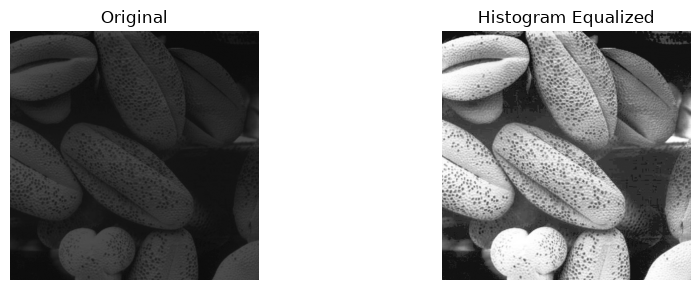

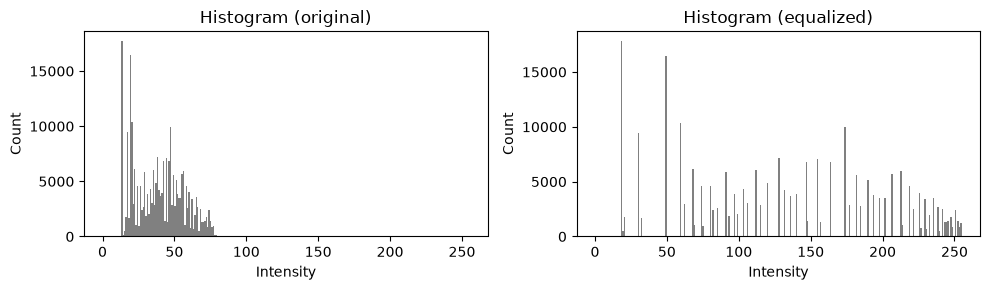

In [52]:
img_leaves = cv.imread("images/q5.tif", cv.IMREAD_GRAYSCALE)
assert img_leaves is not None, "Image not found."

def histogram_equalize(im):
    # Compute histogram (256 bins for 8-bit image)
    hist, _ = np.histogram(im.flatten(), bins=256, range=(0, 256))

    # Cumulative distribution function
    cdf = np.cumsum(hist)
    cdf_normalized = cdf / cdf[-1]  # normalize to [0, 1]

    # Build the mapping: scale to [0, 255] and round
    mapping = np.round(cdf_normalized * 255).astype(np.uint8)

    # Apply mapping via LUT
    equalized = mapping[im]
    return equalized

equalized_leaves = histogram_equalize(img_leaves)

# Display images
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(img_leaves, cmap='gray', vmin=0, vmax=255)
ax[0].set_title('Original'); ax[0].axis('off')

ax[1].imshow(equalized_leaves, cmap='gray', vmin=0, vmax=255)
ax[1].set_title('Histogram Equalized'); ax[1].axis('off')
plt.tight_layout()
plt.show()

# Histograms before and after
fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].hist(img_leaves.ravel(), bins=256, range=(0,255), color='gray')
ax[0].set_title('Histogram (original)')
ax[0].set_xlabel('Intensity'); ax[0].set_ylabel('Count')

ax[1].hist(equalized_leaves.ravel(), bins=256, range=(0,255), color='gray')
ax[1].set_title('Histogram (equalized)')
ax[1].set_xlabel('Intensity'); ax[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

## Question 6

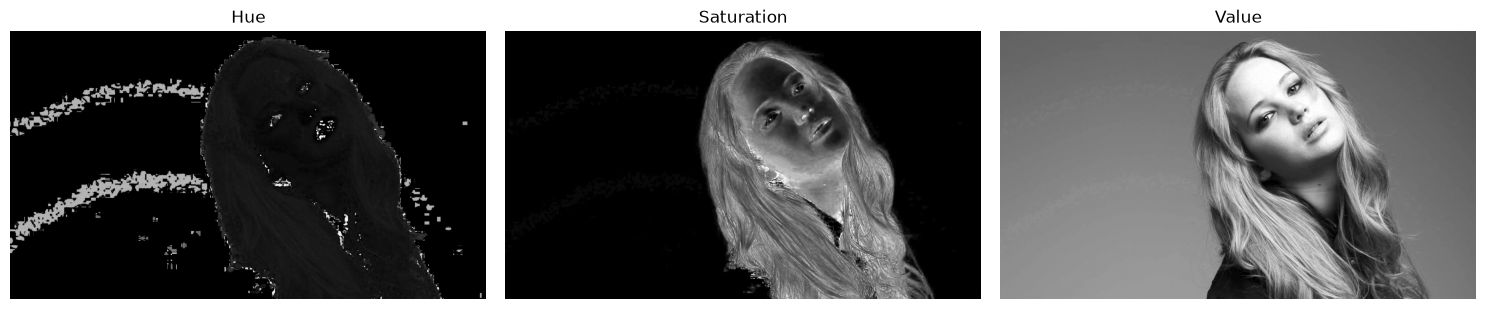

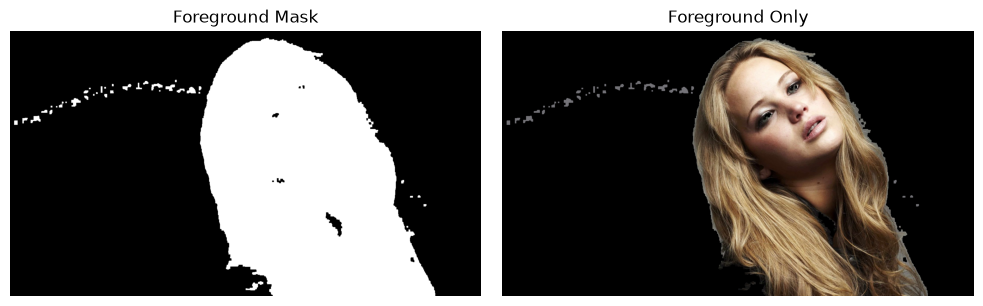

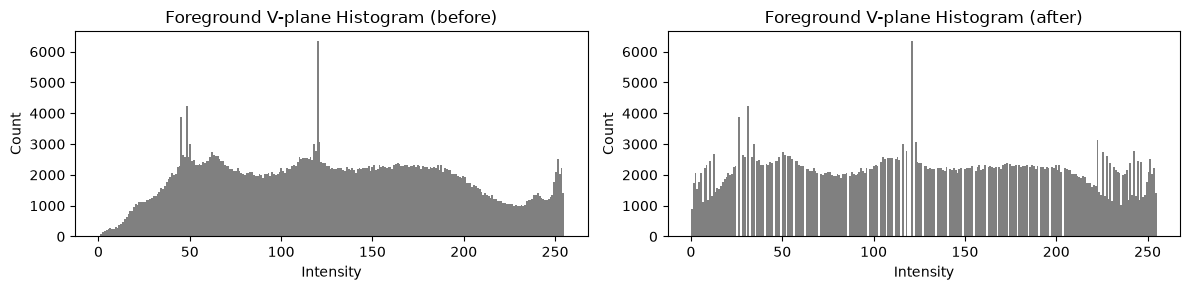

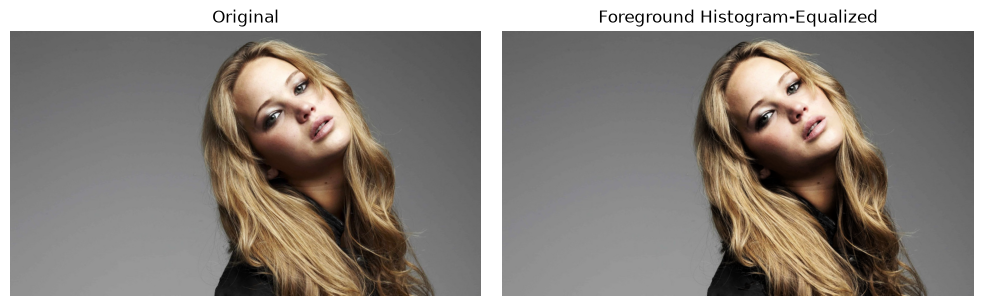

In [59]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_bgr = cv.imread("images/q6.jpeg")
assert img_bgr is not None, "Image not found."

# (a) Split into H, S, V and display in grayscale
img_hsv = cv.cvtColor(img_bgr, cv.COLOR_BGR2HSV)
H, S, V = cv.split(img_hsv)

fig, ax = plt.subplots(1, 3, figsize=(15, 3))
ax[0].imshow(H, cmap='gray'); ax[0].set_title('Hue'); ax[0].axis('off')
ax[1].imshow(S, cmap='gray'); ax[1].set_title('Saturation'); ax[1].axis('off')
ax[2].imshow(V, cmap='gray'); ax[2].set_title('Value'); ax[2].axis('off')
plt.tight_layout()
plt.show()

# (b) Threshold the Saturation plane to get the foreground mask
_, mask = cv.threshold(S, 10, 255, cv.THRESH_BINARY)
kernel = np.ones((5, 5), np.uint8)
mask = cv.morphologyEx(mask, cv.MORPH_OPEN, kernel)
mask = cv.morphologyEx(mask, cv.MORPH_CLOSE, kernel)

# (c) Extract foreground only, in color
foreground_color = cv.bitwise_and(img_bgr, img_bgr, mask=mask)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(mask, cmap='gray')
ax[0].set_title('Foreground Mask'); ax[0].axis('off')

ax[1].imshow(cv.cvtColor(foreground_color, cv.COLOR_BGR2RGB))
ax[1].set_title('Foreground Only'); ax[1].axis('off')
plt.tight_layout()
plt.show()

# Histogram of the foreground's V values (before equalization)
v_fg_pixels = V[mask == 255]
hist, _ = np.histogram(v_fg_pixels, bins=256, range=(0, 256))

# (d) Cumulative sum
cdf = np.cumsum(hist)

# (e) Histogram-equalize the foreground's V values using the CDF formula
cdf_normalized = cdf / cdf[-1]
mapping = np.round(cdf_normalized * 255).astype(np.uint8)
v_equalized_pixels = mapping[v_fg_pixels]

V_equalized = V.copy()
V_equalized[mask == 255] = v_equalized_pixels

# Combined Histograms side-by-side with figure height 3
fig, ax = plt.subplots(1, 2, figsize=(12, 3))

ax[0].hist(v_fg_pixels, bins=256, range=(0, 255), color='gray')
ax[0].set_title('Foreground V-plane Histogram (before)')
ax[0].set_xlabel('Intensity'); ax[0].set_ylabel('Count')

ax[1].hist(v_equalized_pixels, bins=256, range=(0, 255), color='gray')
ax[1].set_title('Foreground V-plane Histogram (after)')
ax[1].set_xlabel('Intensity'); ax[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Merge back into HSV -> BGR to get a full color result
img_hsv_result = cv.merge([H, S, V_equalized])
img_result_bgr = cv.cvtColor(img_hsv_result, cv.COLOR_HSV2BGR)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].imshow(cv.cvtColor(img_bgr, cv.COLOR_BGR2RGB))
ax[0].set_title('Original'); ax[0].axis('off')

ax[1].imshow(cv.cvtColor(img_result_bgr, cv.COLOR_BGR2RGB))
ax[1].set_title('Foreground Histogram-Equalized'); ax[1].axis('off')
plt.tight_layout()
plt.show()